# Xarray + Cloud OISST (One-Month) Basics & Stats

This notebook demonstrates basic **xarray** operations on a **one-month** subset of a cloud-hosted climate dataset: **NOAA OISST v2.1 daily SST** on AWS Public Datasets (NetCDF files). You'll:
- Discover files for one month on S3 with `fsspec`
- Open them with `xarray.open_mfdataset` (anonymous S3)
- Inspect dataset structure
- Subset in space (and within that month)
- Compute basic stats (mean, std, anomalies relative to the month’s mean)
- Make maps of the month-mean and variability

**Deliverables:** Answer the **🧩 Questions** in the markdown prompts. Fill in the code where indicated by `# TODO`.


In [1]:
import xarray as xr
import fsspec
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['figure.dpi'] = 120


## 1) Open the cloud dataset (NetCDF on AWS, one month)

We'll access **NOAA OISST v2.1 (daily)** in the NOAA CDR bucket on AWS. Files are arranged by **YYYYMM**.

**🧩 Questions**
1. What engine are we using to read NetCDF files from S3? **h5netcdf**
2. Why do we need `storage_options={'anon': True}`? **OISST data are hosted in a public dataset on AWS, using anon=True allows us to bypass authentication.**
3. Inspect dataset attributes: what are the units and long name of `sst`? **unit: Celsius; long name: Daily sea surface temperature**


In [28]:
yearmonth = "201812"  # TODO: try other months like "201507" or "201909"
prefix = f"noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/{yearmonth}/oisst-avhrr-v02r01.*.nc"

fs = fsspec.filesystem("s3", anon=True)
paths = sorted(fs.glob(prefix))
print(f"Found {len(paths)} files for {yearmonth}. Example:", paths[:2])

urls = [f"s3://{p}" for p in paths]

ds = xr.open_mfdataset(
    urls,
    engine="h5netcdf",
    combine="by_coords",
    decode_times=True,
    mask_and_scale=True,
    backend_kwargs={"storage_options": {"anon": True}},
    chunks={"time": 1}
)

ds


Found 31 files for 201812. Example: ['noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/201812/oisst-avhrr-v02r01.20181201.nc', 'noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/201812/oisst-avhrr-v02r01.20181202.nc']


<xarray.Dataset> Size: 514MB
Dimensions:  (time: 31, zlev: 1, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 248B 2018-12-01T12:00:00 ... 2018-12-31T12...
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
  * zlev     (zlev) float32 4B 0.0
Data variables:
    anom     (time, zlev, lat, lon) float32 129MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    err      (time, zlev, lat, lon) float32 129MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    ice      (time, zlev, lat, lon) float32 129MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    sst      (time, zlev, lat, lon) float32 129MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
Attributes: (12/37)
    source:                     ICOADS, NCEP_GTS, GSFC_ICE, NCEP_ICE, Pathfin...
    naming_authority:           gov.noaa.ncei
    cdm_data_type:              Grid
    date_modified:              2020-01-18T02:23:00Z
    date_created:               2020-01-18T02:23:00Z
    processing_level:           NOAA Level 4
    ...                         ...
    references:                 Reynolds, et al.(2007) Daily High-Resolution-...
    summary:                    NOAAs 1/4-degree Daily Optimum Interpolation ...
    product_version:            Version v02r01
    platform:                   Ships, buoys, Argo floats, MetOp-A, MetOp-B
    comment:                    Data was converted from NetCDF-3 to NetCDF-4 ...
    id:                         oisst-avhrr-v02r01.20181201.nc

## 2) Explore coordinates & variables

**🧩 Questions**
1. What are the coordinate names for time and space? **time: "time"; space: "lat", "lon", "zlev"**
2. What is the shape of `sst`? **(31, 1, 720, 1440)**
3. How are missing values represented? **-999**


In [29]:
list(ds.data_vars), list(ds.coords)
print("answer for q2:", ds["sst"].shape)
print("answer for q3:", ds["sst"].encoding["_FillValue"])

answer for q2: (31, 1, 720, 1440)
answer for q3: -999


## 3) Time & space subsetting

We'll select a **regional box** (e.g., Gulf of Mexico) within this month.

**🧩 Questions**
1. What lon/lat bounds did you choose? **98W to 93W, 18N to 32 N**
2. How many daily steps are present in this month? **31**


In [30]:
var = "sst"

lon_min, lon_max = -98, -83   # TODO
lat_min, lat_max =  18,  32   # TODO

def to_0360(lon):
    lon = np.asarray(lon)
    out = np.mod(lon, 360.0)
    out[out < 0] += 360.0
    return out

lon_min_0360, lon_max_0360 = to_0360([lon_min, lon_max])

dss = ds.sel(
    lon=slice(lon_min_0360, lon_max_0360),
    lat=slice(lat_min, lat_max)
)

dss[var]


<xarray.DataArray 'sst' (time: 31, zlev: 1, lat: 56, lon: 60)> Size: 417kB
dask.array<getitem, shape=(31, 1, 56, 60), dtype=float32, chunksize=(1, 1, 56, 60), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 248B 2018-12-01T12:00:00 ... 2018-12-31T12...
  * lat      (lat) float32 224B 18.12 18.38 18.62 18.88 ... 31.38 31.62 31.88
  * lon      (lon) float32 240B 262.1 262.4 262.6 262.9 ... 276.4 276.6 276.9
  * zlev     (zlev) float32 4B 0.0
Attributes:
    long_name:  Daily sea surface temperature
    valid_min:  -300
    valid_max:  4500
    units:      Celsius

## 4) Basic statistics

Compute region-wide stats through time and over space **within this month**.

**🧩 Questions**
1. Compute the spatial mean SST time series over your box. What is the monthly average and standard deviation? **monthly average: 24.33 $^\circ$C, standard deviation: 0.519**
2. Compute within-month anomalies (subtract the month-mean). What are the largest positive and negative anomalies? **1.002, -0.650**
3. What day had the warmest/coolest region-mean SST? **Warmest day: 2018-12-01, coolest day: 2018-12-23**


Month mean SST (°C): 24.33380126953125
Month std SST (°C): 0.5193397402763367


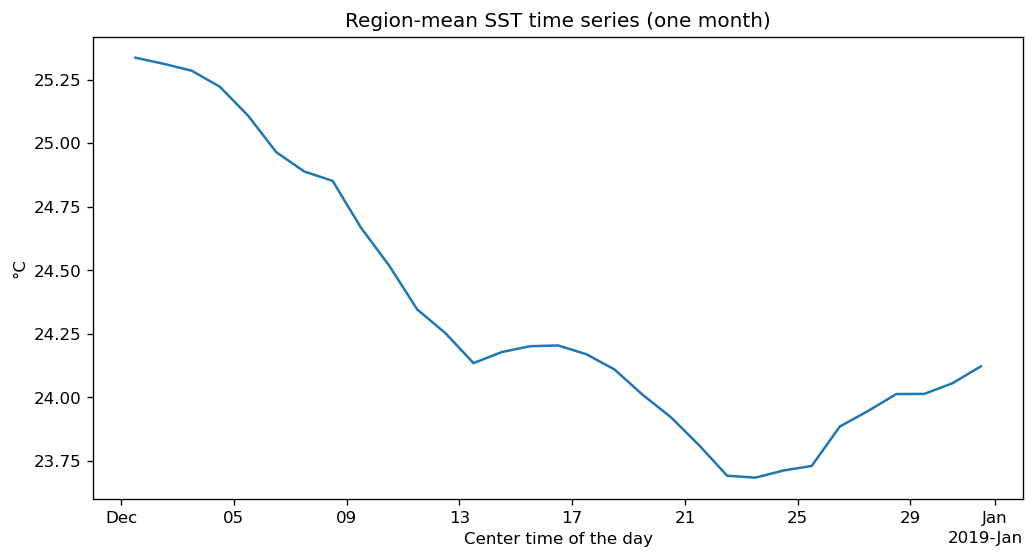

Warmest day: 2018-12-01 25.33587074279785 , anomaly: 1.0020694732666016
Coolest day: 2018-12-23 23.68416404724121 , anomaly: -0.6496372222900391


/var/folders/4v/xs1f8bws5vj6gd4p9n0gl_6h0000gr/T/ipykernel_29869/3293325561.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Warmest day:', pd.to_datetime(ts.time[imax].values).date(), float(ts.isel(time=imax).values), ", anomaly:", float(ts.isel(time=imax).values - ts_mean.values))
/var/folders/4v/xs1f8bws5vj6gd4p9n0gl_6h0000gr/T/ipykernel_29869/3293325561.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Coolest day:', pd.to_datetime(ts.time[imin].values).date(), float(ts.isel(time=imin).values), ", anomaly:", float(ts.isel(time=imin).values - ts_mean.values))


In [31]:
ts = dss[var].mean(dim=['lat','lon'])

ts_mean = ts.mean().compute()
ts_std  = ts.std().compute()
print('Month mean SST (°C):', float(ts_mean.values))
print('Month std SST (°C):', float(ts_std.values))

ts.load().plot()
plt.title('Region-mean SST time series (one month)')
plt.ylabel('°C')
plt.show()

imax = int(ts.argmax('time'))
imin = int(ts.argmin('time'))
print('Warmest day:', pd.to_datetime(ts.time[imax].values).date(), float(ts.isel(time=imax).values), ", anomaly:", float(ts.isel(time=imax).values - ts_mean.values))
print('Coolest day:', pd.to_datetime(ts.time[imin].values).date(), float(ts.isel(time=imin).values), ", anomaly:", float(ts.isel(time=imin).values - ts_mean.values))


Max anomaly (°C): 1.0020694732666016
Min anomaly (°C): -0.6496381759643555


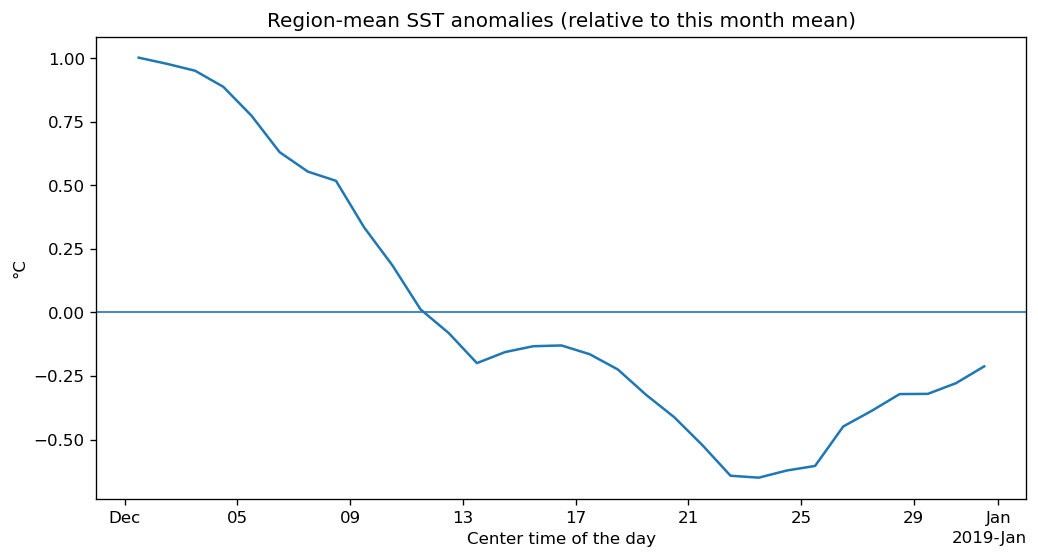

In [32]:
month_mean = dss[var].mean('time')
anom = dss[var] - month_mean

ts_anom = anom.mean(dim=['lat','lon'])
print('Max anomaly (°C):', float(ts_anom.max().compute().values))
print('Min anomaly (°C):', float(ts_anom.min().compute().values))

ts_anom.load().plot()
plt.title('Region-mean SST anomalies (relative to this month mean)')
plt.axhline(0, lw=1)
plt.ylabel('°C')
plt.show()


## 5) Regional maps: month-mean and variability

Make maps of month-mean SST and within-month variability (std and range).

**🧩 Questions**
1. What patterns do you notice? **A warm Loop Current located in the eastern Gulf of Mexico, extending northward.**
2. Where is variability strongest? **The northern coast of the Gulf of Mexico**


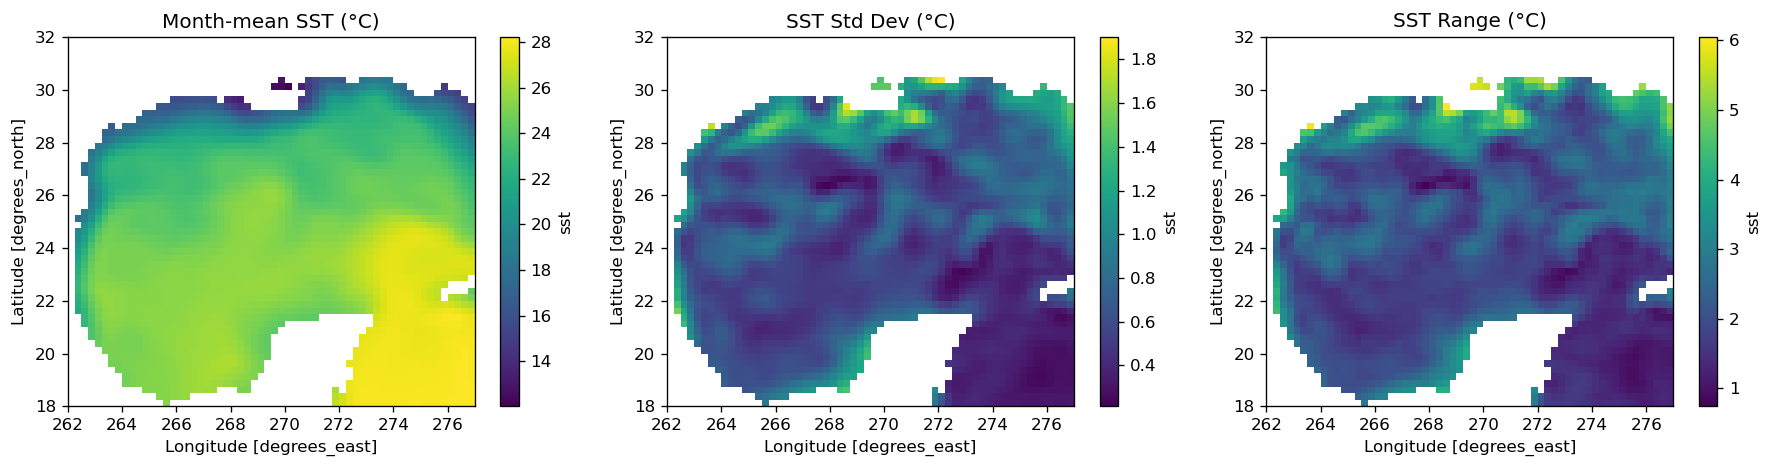

In [33]:
mean_sst = dss[var].mean('time')
std_sst  = dss[var].std('time')
range_sst = dss[var].max('time') - dss[var].min('time')

fig = plt.figure(figsize=(15,4))
ax = plt.subplot(1,3,1); mean_sst.plot(ax=ax); ax.set_title('Month-mean SST (°C)')
ax = plt.subplot(1,3,2); std_sst.plot(ax=ax); ax.set_title('SST Std Dev (°C)')
ax = plt.subplot(1,3,3); range_sst.plot(ax=ax); ax.set_title('SST Range (°C)')
plt.tight_layout(); plt.show()


## 6) Export a small subset for sharing (Check In Problem for Module 2)

Write a NetCDF with your regional mean time series and month-mean/variability maps.  Upload with your committed repository.

In [35]:
ds_output = xr.Dataset({
    "SST_region_mean": ts,
    "SST_monthly_mean": mean_sst,
    "SST_monthly_std": std_sst,
})
ds_output["SST_region_mean"].attrs["units"] = "Celsius"
ds_output["SST_region_mean"].attrs["long_name"] = "Regional mean sea surface temperature"
ds_output["SST_monthly_mean"].attrs["units"] = "Celsius"
ds_output["SST_monthly_mean"].attrs["long_name"] = "Monthly mean sea surface temperature"
ds_output["SST_monthly_std"].attrs["units"] = "unitless"
ds_output["SST_monthly_std"].attrs["long_name"] = "Monthly standard deviation of sea surface temperature"
ds_output.to_netcdf("Mean_SST.nc")